Import the dataset and analyse

In [ ]:
import pandas as pd

URL = "https://c.smartrecruiters.com/sr-company-attachments-prod-aws-dc5/5d2ed57b90bf6f4af4b0ed99/643528b1-8871-4e4d-8cb6-475cb10b9925?r=s3-eu-central-1"
df_raw = pd.read_csv(URL, na_values=["NA", " ", ""])
df_raw = df_raw.drop(columns=[c for c in ["Unnamed: 0", "customerID"] if c in df_raw.columns])
df_raw.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,NaN,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,NaN,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,NaN,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,NaN,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Balance Churn :", df_raw["Churn"].value_counts(normalize=True).round(3).to_dict())

print(df_raw.dtypes)

print("Manquants par colonne :")
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])

Balance Churn : {'No': 0.735, 'Yes': 0.265}
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
Manquants par colonne :
OnlineBackup       5634
TechSupport        1526
StreamingTV        1526
StreamingMovies    1526
TotalCharges       2122
dtype: int64


**Data Cleaning**

In [ ]:
df = df_raw.copy()

# TotalCharges, on reconstruit
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"])

services = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

# Si pas internet, pas de service internet : "No internet service"
no_net = df["InternetService"].eq("No")
for c in services:
    df.loc[no_net, c] = df.loc[no_net, c].fillna("No internet service")

# OnlineBackup : bcp de manquants donc unknown
df["OnlineBackup"] = df["OnlineBackup"].fillna("Unknown")

# Reste des services : vrais manquants = non souscrit -> "No"
df[services] = df[services].fillna("No")

# Churn
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("manquants restants :", df.isna().sum().sum())

manquants restants : 0


### Objectif 1

Caractéristiques associées au churn

In [ ]:
print("Churn global :", round(df["Churn"].mean()*100, 1))

groupes = {
    "DEMOGRAPHIE": ["gender", "SeniorCitizen", "Partner", "Dependents"],
    "CONTRAT":     ["Contract", "PaperlessBilling", "PaymentMethod"],
    "SERVICES":    ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                    "TechSupport", "StreamingTV", "StreamingMovies", "PhoneService", "MultipleLines"],
}
for titre, cols in groupes.items():
    print(titre)
    for c in cols:
        print(" ", c, ":", (df.groupby(c)["Churn"].mean()*100).round(1).to_dict())

df["tenure_bin"] = pd.cut(df["tenure"], [-1,6,12,24,48,72], labels=["0-6","7-12","13-24","25-48","49-72"])
print("ANCIENNETE / PRIX")
print("  tenure_bin :", (df.groupby("tenure_bin", observed=True)["Churn"].mean()*100).round(1).to_dict())
print(df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].mean().round(1))

Churn global : 26.5
DEMOGRAPHIE
  gender : {'Female': 26.9, 'Male': 26.2}
  SeniorCitizen : {0: 23.6, 1: 41.7}
  Partner : {'No': 33.0, 'Yes': 19.7}
  Dependents : {'No': 31.3, 'Yes': 15.5}
CONTRAT
  Contract : {'Month-to-month': 42.7, 'One year': 11.3, 'Two year': 2.8}
  PaperlessBilling : {'No': 16.3, 'Yes': 33.6}
  PaymentMethod : {'Bank transfer (automatic)': 16.7, 'Credit card (automatic)': 15.2, 'Electronic check': 45.3, 'Mailed check': 19.1}
SERVICES
  InternetService : {'DSL': 19.0, 'Fiber optic': 41.9, 'No': 7.4}
  OnlineSecurity : {'No': 41.8, 'No internet service': 7.4, 'Yes': 14.6}
  OnlineBackup : {'No': 40.8, 'No internet service': 7.4, 'Unknown': 31.9, 'Yes': 19.1}
  DeviceProtection : {'No': 39.1, 'No internet service': 7.4, 'Yes': 22.5}
  TechSupport : {'No': 41.6, 'No internet service': 7.4, 'Yes': 15.2}
  StreamingTV : {'No': 33.5, 'No internet service': 7.4, 'Yes': 30.1}
  StreamingMovies : {'No': 33.7, 'No internet service': 7.4, 'Yes': 29.9}
  PhoneService : {'No'

Quelques graphiques

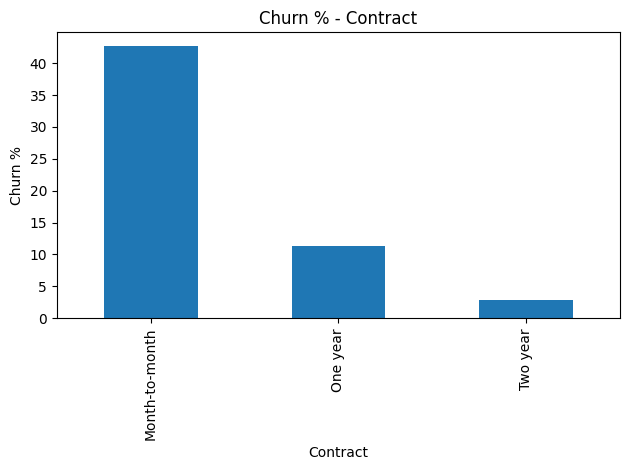

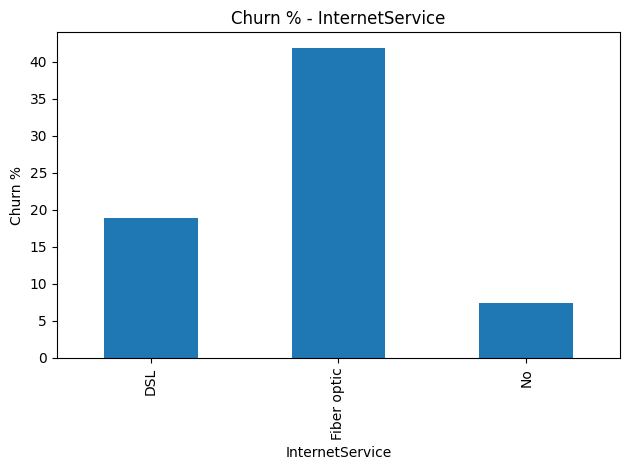

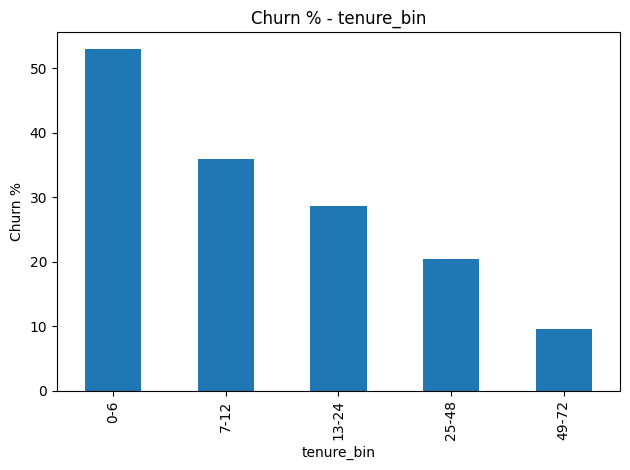

In [ ]:
import matplotlib.pyplot as plt

for col in ["Contract", "InternetService", "tenure_bin"]:
    (df.groupby(col, observed=True)["Churn"].mean()*100).plot.bar(title=f"Churn % - {col}")
    plt.ylabel("Churn %"); plt.tight_layout(); plt.show()

Hypothèse Client

In [ ]:
df["num_services"] = (
    df["PhoneService"].eq("Yes").astype(int)
    + df["MultipleLines"].eq("Yes").astype(int)
    + df["InternetService"].isin(["DSL","Fiber optic"]).astype(int)
    + df[services].eq("Yes").sum(axis=1)
)
print("\nChurn par num_services :", (df.groupby("num_services")["Churn"].mean()*100).round(1))
print("corr(num_services, Churn) :", round(df["num_services"].corr(df["Churn"]), 3))



Churn par num_services : num_services
1    11.4
2    31.2
3    42.5
4    34.6
5    29.2
6    25.7
7    18.4
8     7.1
9     9.5
Name: Churn, dtype: float64
corr(num_services, Churn) : -0.008


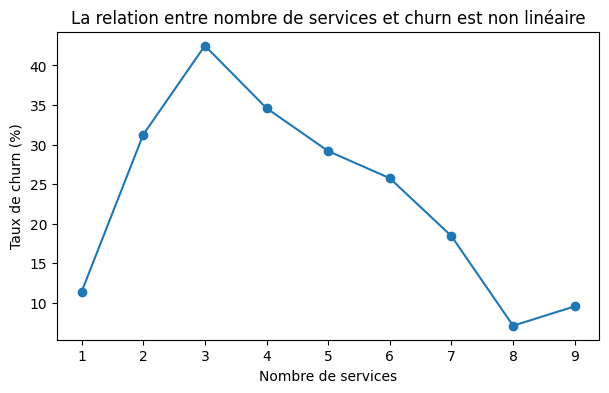

In [ ]:
service_summary = (
    df.groupby("num_services")["Churn"]
    .agg(
        clients="size",
        churn_rate="mean"
    )
    .reset_index()
)

service_summary["churn_rate"] *= 100

plt.figure(figsize=(7, 4))
plt.plot(
    service_summary["num_services"],
    service_summary["churn_rate"],
    marker="o"
)
plt.xlabel("Nombre de services")
plt.ylabel("Taux de churn (%)")
plt.title("La relation entre nombre de services et churn est non linéaire")
plt.show()

### Objectif 2 : Prédire

Baseline

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

y = df["Churn"]
features = df.drop(columns=["Churn", "tenure_bin"])     # tenure_bin sert juste a l'EDA
num = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]
cat = [c for c in features.columns if c not in num]

pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])

X_tr, X_te, y_tr, y_te = train_test_split(features, y, test_size=0.2, stratify=y, random_state=42)

dummy = Pipeline([
    ("pre", pre),
    ("classifier", DummyClassifier(strategy="prior"))
])

dummy.fit(X_tr, y_tr)

dummy_proba = dummy.predict_proba(X_te)[:, 1]

print("Dummy ROC-AUC :",roc_auc_score(y_te, dummy_proba))
print(classification_report(y_te, dummy.predict(X_te), digits=3))

Dummy ROC-AUC : 0.5
              precision    recall  f1-score   support

           0      0.735     1.000     0.847      1035
           1      0.000     0.000     0.000       374

    accuracy                          0.735      1409
   macro avg      0.367     0.500     0.423      1409
weighted avg      0.540     0.735     0.622      1409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Modèle 1

In [ ]:

model = Pipeline([("pre", pre),
                  ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))])


model.fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]
print("ROC-AUC :", round(roc_auc_score(y_te, proba), 3))
print(classification_report(y_te, model.predict(X_te), digits=3))

ROC-AUC : 0.842
              precision    recall  f1-score   support

           0      0.903     0.722     0.802      1035
           1      0.505     0.786     0.615       374

    accuracy                          0.739      1409
   macro avg      0.704     0.754     0.709      1409
weighted avg      0.798     0.739     0.753      1409



In [ ]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(model,X_te,y_te,scoring="roc_auc",n_repeats=10,random_state=42)

importance_df = pd.DataFrame({"feature": X_te.columns, "importance": importance.importances_mean}).sort_values("importance",ascending=False)

display(importance_df.head(10))

,feature,importance
4,tenure,0.158412
7,InternetService,0.057864
17,MonthlyCharges,0.042831
14,Contract,0.038256
18,TotalCharges,0.012266
19,num_services,0.006476
8,OnlineSecurity,0.004672
11,TechSupport,0.003729
16,PaymentMethod,0.003367
13,StreamingMovies,0.002669
